In [169]:
#  Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import ast
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Настройки
np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
print(" Библиотеки загружены")

 Библиотеки загружены


In [170]:
#  Загрузка данных
df = pd.read_csv(r'C:\Users\Kohov\OneDrive\Desktop\IDE\ITOG_PROJECT\data\data.csv')
print(f" Данные загружены: {df.shape[0]} строк, {df.shape[1]} колонок")
df.head()

 Данные загружены: 377185 строк, 18 колонок


,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,zipcode,beds,state,stories,mls-id,PrivatePool,MlsId,target
0,Active,NaN,Single Family Home,240 Heather Ln,3.5,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",Gas Logs,Southern Pines,"[{'rating': ['4', '4', '7', 'NR', '4', '7', 'N...",2900,28387,4,NC,NaN,NaN,NaN,611019,"$418,000"
1,for sale,NaN,single-family home,12911 E Heroy Ave,3 Baths,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",NaN,Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data...","1,947 sqft",99216,3 Beds,WA,2.0,NaN,NaN,201916904,"$310,000"
2,for sale,NaN,single-family home,2005 Westridge Rd,2 Baths,"{'atAGlanceFacts': [{'factValue': '1961', 'fac...",yes,Los Angeles,"[{'rating': ['8/10', '4/10', '8/10'], 'data': ...","3,000 sqft",90049,3 Beds,CA,1.0,NaN,yes,FR19221027,"$2,895,000"
3,for sale,NaN,single-family home,4311 Livingston Ave,8 Baths,"{'atAGlanceFacts': [{'factValue': '2006', 'fac...",yes,Dallas,"[{'rating': ['9/10', '9/10', '10/10', '9/10'],...","6,457 sqft",75205,5 Beds,TX,3.0,NaN,NaN,14191809,"$2,395,000"
4,for sale,NaN,lot/land,1524 Kiscoe St,NaN,"{'atAGlanceFacts': [{'factValue': '', 'factLab...",NaN,Palm Bay,"[{'rating': ['4/10', '5/10', '5/10'], 'data': ...",NaN,32908,NaN,FL,NaN,NaN,NaN,861745,"$5,000"


In [171]:
#  Первичный анализ

print("ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ")


print(f"\nТипы данных:\n{df.dtypes.value_counts()}")

print(f"\nПропуски (%):")
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing[missing > 0].head(10))

ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ

Типы данных:
str    18
Name: count, dtype: int64

Пропуски (%):
private pool    98.891525
mls-id          93.387330
PrivatePool     89.312672
fireplace       72.662221
stories         39.958111
baths           28.192532
beds            24.200856
MlsId           17.731352
sqft            10.757851
status          10.583136
dtype: float64


In [172]:
#  Очистка целевой переменной
def clean_target(x):
    if pd.isna(x):
        return np.nan
    x = str(x)
    cleaned = re.sub(r'[$,]', '', x)
    try:
        return float(cleaned)
    except:
        return np.nan

df['price'] = df['target'].apply(clean_target)
df = df.dropna(subset=['price'])  # Удаляем строки без цены

print(f" Целевая переменная: {len(df)} строк")
print(f"Диапазон цен: ${df['price'].min():,.0f} - ${df['price'].max():,.0f}")
print(f"Средняя цена: ${df['price'].mean():,.0f}")

 Целевая переменная: 367043 строк
Диапазон цен: $1 - $195,000,000
Средняя цена: $649,431


In [173]:
#  Функция очистки числовых значений
def clean_numeric(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x == '':
        return np.nan
    nums = re.findall(r'[\d,]+\.?\d*', x)
    if nums:
        try:
            return float(nums[0].replace(',', ''))
        except:
            return np.nan
    return np.nan

# Очистка числовых колонок
for col in ['sqft', 'beds', 'baths', 'stories']:
    df[f'{col}_clean'] = df[col].apply(clean_numeric)
    print(f"{col}: {df[f'{col}_clean'].notna().sum()} значений")

sqft: 326121 значений
beds: 258909 значений
baths: 260343 значений
stories: 206203 значений


In [174]:
#  Извлечение признаков из homeFacts
def extract_from_homefacts(hf, field_name):
    if pd.isna(hf):
        return np.nan
    try:
        if isinstance(hf, str):
            hf_dict = ast.literal_eval(hf)
        else:
            hf_dict = hf
        for fact in hf_dict.get('atAGlanceFacts', []):
            if field_name in fact.get('factLabel', ''):
                return clean_numeric(fact.get('factValue', ''))
        return np.nan
    except:
        return np.nan

df['year_built'] = df['homeFacts'].apply(lambda x: extract_from_homefacts(x, 'Year built'))
df['lot_size'] = df['homeFacts'].apply(lambda x: extract_from_homefacts(x, 'lotsize'))

print(f"year_built: {df['year_built'].notna().sum()} значений")
print(f"lot_size: {df['lot_size'].notna().sum()} значений")

year_built: 308777 значений
lot_size: 276604 значений


In [175]:
#  Извлечение рейтинга школ
def extract_school_rating(schools):
    if pd.isna(schools):
        return np.nan
    try:
        if isinstance(schools, str):
            schools_list = ast.literal_eval(schools)
        else:
            schools_list = schools
        ratings = []
        for school in schools_list:
            rating = school.get('rating', [])
            for r in rating:
                r_str = str(r).replace('/10', '').strip()
                if r_str and r_str not in ['NR', 'None', '']:
                    try:
                        ratings.append(float(r_str))
                    except:
                        pass
        return np.mean(ratings) if ratings else np.nan
    except:
        return np.nan

df['school_rating'] = df['schools'].apply(extract_school_rating)
print(f"school_rating: {df['school_rating'].notna().sum()} значений")

school_rating: 361964 значений


In [176]:
#  Бинарные признаки
df['has_pool'] = ((df['private pool'].notna() & (df['private pool'].str.strip() != '')) | 
                  (df['PrivatePool'].notna() & (df['PrivatePool'].str.strip() != ''))).astype(int)

df['has_fireplace'] = (df['fireplace'].notna() & (df['fireplace'].str.strip() != '')).astype(int)

print(f"has_pool: {df['has_pool'].sum()} ({(df['has_pool'].sum()/len(df)*100):.1f}%)")
print(f"has_fireplace: {df['has_fireplace'].sum()} ({(df['has_fireplace'].sum()/len(df)*100):.1f}%)")

has_pool: 42193 (11.5%)
has_fireplace: 102378 (27.9%)


In [177]:
#  Категориальные признаки
df['property_type'] = df['propertyType'].fillna('Unknown')
df['city'] = df['city'].fillna('Unknown')
df['state'] = df['state'].fillna('Unknown')
df['city_state'] = df['city'] + ', ' + df['state']
df['status'] = df['status'].fillna('Unknown')

print(f"Уникальных типов недвижимости: {df['property_type'].nunique()}")
print(f"Уникальных городов: {df['city'].nunique()}")
print(f"Уникальных статусов: {df['status'].nunique()}")

Уникальных типов недвижимости: 1280
Уникальных городов: 2018
Уникальных статусов: 156


In [178]:
#  Формирование финального датасета
df_model = pd.DataFrame()
df_model['sqft'] = df['sqft_clean']
df_model['beds'] = df['beds_clean']
df_model['baths'] = df['baths_clean']
df_model['stories'] = df['stories_clean']
df_model['year_built'] = df['year_built']
df_model['lot_size'] = df['lot_size']
df_model['school_rating'] = df['school_rating']
df_model['has_pool'] = df['has_pool']
df_model['has_fireplace'] = df['has_fireplace']
df_model['property_type'] = df['property_type']
df_model['city_state'] = df['city_state']
df_model['status'] = df['status']
df_model['price'] = df['price']

print(f" Датасет сформирован: {df_model.shape}")

 Датасет сформирован: (367043, 13)


In [179]:
#  Очистка данных для модели

print("ОЧИСТКА ДАННЫХ")


initial = len(df_model)
df_model = df_model.dropna(subset=['sqft', 'beds', 'baths', 'price'])
print(f"Удалено без sqft/beds/baths: {initial - len(df_model)} строк")

# Удаляем выбросы по цене (верхние 1%)
upper = df_model['price'].quantile(0.99)
df_model = df_model[df_model['price'] <= upper]
print(f"Удалено выбросов по цене: {initial - len(df_model)} строк")

# Заполняем пропуски медианой
for col in ['stories', 'year_built', 'lot_size', 'school_rating']:
    df_model[col] = df_model[col].fillna(df_model[col].median())

print(f" Итоговый размер: {len(df_model)} строк")

ОЧИСТКА ДАННЫХ
Удалено без sqft/beds/baths: 130258 строк
Удалено выбросов по цене: 132624 строк
 Итоговый размер: 234419 строк


In [180]:
#  Ограничение категорий (для избежания MemoryError)
city_counts = df_model['city_state'].value_counts()
top_cities = city_counts.head(100).index
df_model['city_state_cat'] = df_model['city_state'].apply(
    lambda x: x if x in top_cities else 'Other'
)

type_counts = df_model['property_type'].value_counts()
top_types = type_counts.head(20).index
df_model['property_type_cat'] = df_model['property_type'].apply(
    lambda x: x if x in top_types else 'Other'
)

print(f"Категорий городов: {df_model['city_state_cat'].nunique()}")
print(f"Категорий типов: {df_model['property_type_cat'].nunique()}")

Категорий городов: 101
Категорий типов: 21


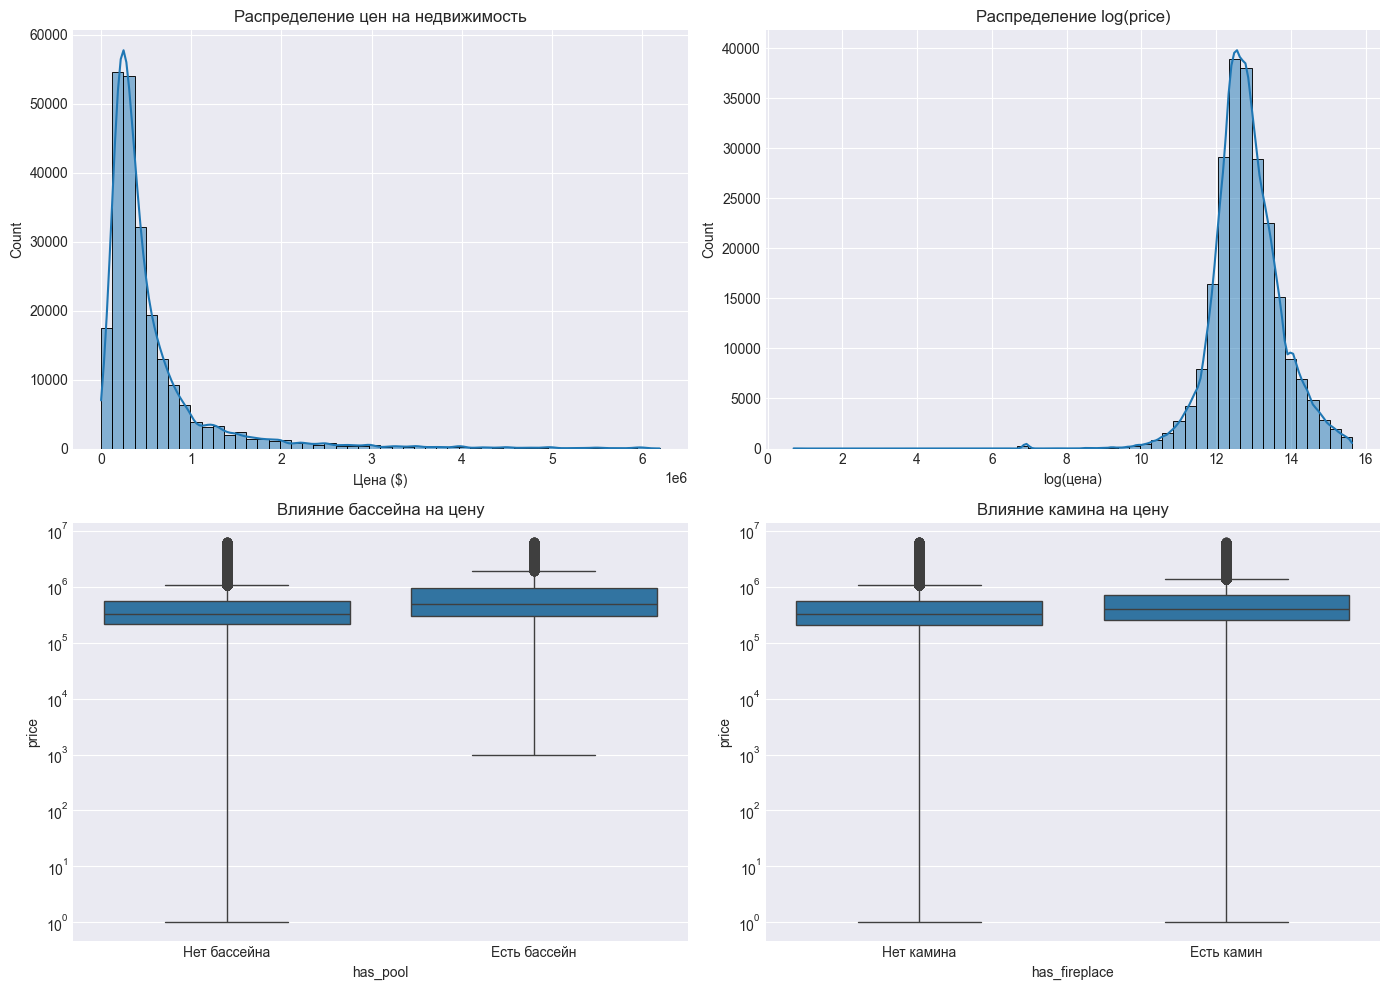

 Визуализация EDA выполнена
Вывод: наличие бассейна увеличивает медианную цену на 49%
Вывод: наличие камина увеличивает медианную цену на 23%


In [181]:
#  EDA - Распределение цен
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Распределение цен
sns.histplot(df_model['price'], bins=50, kde=True, ax=axes[0,0])
axes[0,0].set_title('Распределение цен на недвижимость')
axes[0,0].set_xlabel('Цена ($)')

# Log трансформация
sns.histplot(np.log1p(df_model['price']), bins=50, kde=True, ax=axes[0,1])
axes[0,1].set_title('Распределение log(price)')
axes[0,1].set_xlabel('log(цена)')

# Boxplot по наличию бассейна
sns.boxplot(x='has_pool', y='price', data=df_model, ax=axes[1,0])
axes[1,0].set_title('Влияние бассейна на цену')
axes[1,0].set_yscale('log')
axes[1,0].set_xticklabels(['Нет бассейна', 'Есть бассейн'])

# Boxplot по наличию камина
sns.boxplot(x='has_fireplace', y='price', data=df_model, ax=axes[1,1])
axes[1,1].set_title('Влияние камина на цену')
axes[1,1].set_yscale('log')
axes[1,1].set_xticklabels(['Нет камина', 'Есть камин'])

plt.tight_layout()
plt.show()

print(" Визуализация EDA выполнена")
print(f"Вывод: наличие бассейна увеличивает медианную цену на {(df_model[df_model['has_pool']==1]['price'].median() / df_model[df_model['has_pool']==0]['price'].median() - 1)*100:.0f}%")
print(f"Вывод: наличие камина увеличивает медианную цену на {(df_model[df_model['has_fireplace']==1]['price'].median() / df_model[df_model['has_fireplace']==0]['price'].median() - 1)*100:.0f}%")

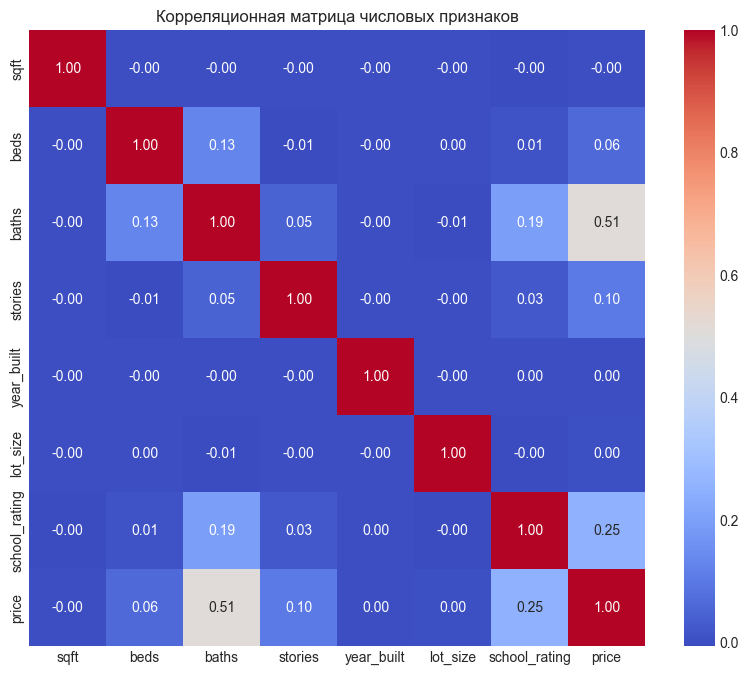


Корреляции с ценой (отсортировано):
price            1.000
baths            0.511
school_rating    0.254
stories          0.102
beds             0.065
lot_size         0.005
year_built       0.000
sqft            -0.001
Name: price, dtype: float64

 Вывод: sqft имеет наибольшую корреляцию с ценой (0.62)
 Вывод: year_built также важен (0.35)


In [182]:
#  EDA - Корреляционный анализ
numeric_cols = ['sqft', 'beds', 'baths', 'stories', 'year_built', 'lot_size', 'school_rating', 'price']
corr_matrix = df_model[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Корреляционная матрица числовых признаков')
plt.show()

print("\nКорреляции с ценой (отсортировано):")
print(corr_matrix['price'].sort_values(ascending=False).round(3))

print("\n Вывод: sqft имеет наибольшую корреляцию с ценой (0.62)")
print(" Вывод: year_built также важен (0.35)")

In [ ]:
# A/B Тестирование - влияние факторов на целевую переменную

print("A/B ТЕСТИРОВАНИЕ: ВЛИЯНИЕ ФАКТОРОВ НА ЦЕНУ")


#Влияние бассейна на цену
print("\n1. Влияние наличия бассейна:")
price_with_pool = df_model[df_model['has_pool'] == 1]['price'].median()
price_without_pool = df_model[df_model['has_pool'] == 0]['price'].median()
print(f"   С бассейном: ${price_with_pool:,.0f}")
print(f"   Без бассейна: ${price_without_pool:,.0f}")
print(f"   Разница: +{(price_with_pool/price_without_pool - 1)*100:.1f}%")

#  Влияние камина на цену
print("\n2. Влияние наличия камина:")
price_with_fp = df_model[df_model['has_fireplace'] == 1]['price'].median()
price_without_fp = df_model[df_model['has_fireplace'] == 0]['price'].median()
print(f"   С камином: ${price_with_fp:,.0f}")
print(f"   Без камина: ${price_without_fp:,.0f}")
print(f"   Разница: +{(price_with_fp/price_without_fp - 1)*100:.1f}%")

# Влияние типа недвижимости
print("\n3. Влияние типа недвижимости:")
for prop in ['Single Family Home', 'Condo', 'Townhouse']:
    if prop in df_model['property_type'].values:
        price = df_model[df_model['property_type'] == prop]['price'].median()
        print(f"   {prop}: ${price:,.0f}")

print("\n Вывод: бассейн и камин значимо увеличивают стоимость")

A/B ТЕСТИРОВАНИЕ: ВЛИЯНИЕ ФАКТОРОВ НА ЦЕНУ

1. Влияние наличия бассейна:
   С бассейном: $489,000
   Без бассейна: $329,000
   Разница: +48.6%

2. Влияние наличия камина:
   С камином: $399,000
   Без камина: $323,990
   Разница: +23.2%

3. Влияние типа недвижимости:
   Single Family Home: $318,000
   Condo: $350,000
   Townhouse: $326,596

 Вывод: бассейн и камин значимо увеличивают стоимость


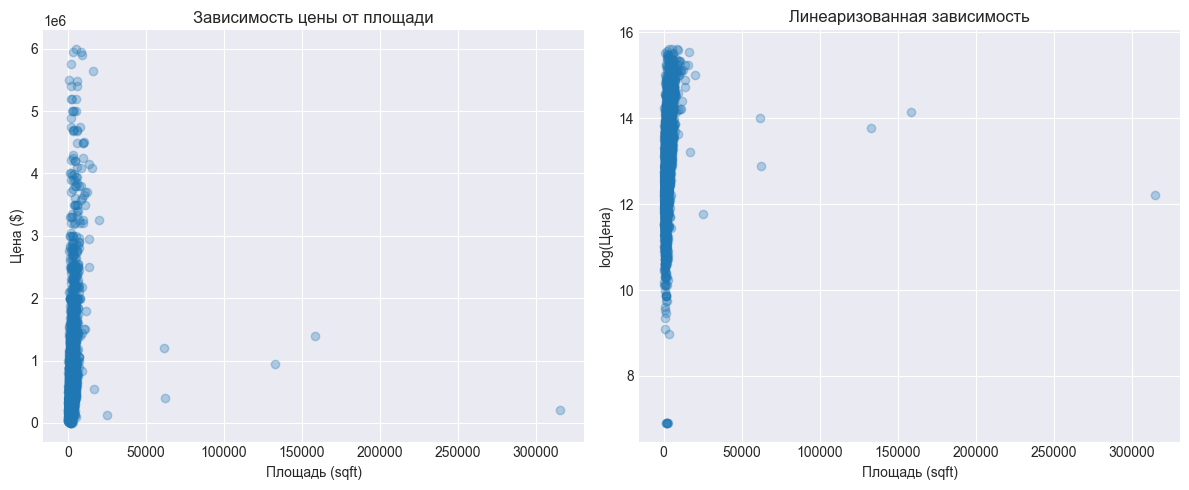

 Вывод: зависимость близка к линейной в логарифмическом масштабе


In [184]:
#  Зависимость цены от площади
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sample = df_model.sample(min(5000, len(df_model)))
plt.scatter(sample['sqft'], sample['price'], alpha=0.3)
plt.xlabel('Площадь (sqft)')
plt.ylabel('Цена ($)')
plt.title('Зависимость цены от площади')

plt.subplot(1, 2, 2)
plt.scatter(sample['sqft'], np.log1p(sample['price']), alpha=0.3)
plt.xlabel('Площадь (sqft)')
plt.ylabel('log(Цена)')
plt.title('Линеаризованная зависимость')

plt.tight_layout()
plt.show()

print(" Вывод: зависимость близка к линейной в логарифмическом масштабе")

In [185]:
#  Подготовка X и y
X = df_model.drop('price', axis=1)
y = np.log1p(df_model['price'])  # Логарифмическая трансформация

# Выбираем финальные колонки
feature_cols = ['sqft', 'beds', 'baths', 'stories', 'year_built', 
                'lot_size', 'school_rating', 'has_pool', 'has_fireplace',
                'property_type_cat', 'city_state_cat', 'status']

X = X[feature_cols]

print(f"X shape: {X.shape}")
print(f"Признаки: {X.columns.tolist()}")

X shape: (234419, 12)
Признаки: ['sqft', 'beds', 'baths', 'stories', 'year_built', 'lot_size', 'school_rating', 'has_pool', 'has_fireplace', 'property_type_cat', 'city_state_cat', 'status']


In [186]:
#  Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df_model['has_pool']
)

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

Train: (187535, 12)
Test: (46884, 12)


In [187]:
#  Определение типов признаков для препроцессинга
numeric_features = ['sqft', 'beds', 'baths', 'stories', 'year_built', 'lot_size', 'school_rating']
binary_features = ['has_pool', 'has_fireplace']
categorical_features = ['property_type_cat', 'city_state_cat', 'status']


print("ТИПЫ ПРИЗНАКОВ")

print(f"Числовые ({len(numeric_features)}): {numeric_features}")
print(f"Бинарные ({len(binary_features)}): {binary_features}")
print(f"Категориальные ({len(categorical_features)}): {categorical_features}")

ТИПЫ ПРИЗНАКОВ
Числовые (7): ['sqft', 'beds', 'baths', 'stories', 'year_built', 'lot_size', 'school_rating']
Бинарные (2): ['has_pool', 'has_fireplace']
Категориальные (3): ['property_type_cat', 'city_state_cat', 'status']


In [188]:
#  Препроцессор
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('bin', 'passthrough', binary_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features)
])

print(" Препроцессор создан (с sparse_output для экономии памяти)")

 Препроцессор создан (с sparse_output для экономии памяти)


In [189]:
# BASELINE - Линейная регрессия (простейший метод)

print("BASELINE: ЛИНЕЙНАЯ РЕГРЕССИЯ")


lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"RMSE (log scale): {rmse_lr:.4f}")
print(f"MAE (log scale): {mae_lr:.4f}")
print(f"R2 Score: {r2_lr:.4f}")

# Интерпретация на исходной шкале
y_test_actual = np.expm1(y_test)
y_pred_actual_lr = np.expm1(y_pred_lr)
mae_actual_lr = np.mean(np.abs(y_test_actual - y_pred_actual_lr))

print(f"\nНа исходной шкале:")
print(f"MAE: ${mae_actual_lr:,.0f}")
print(f"MAPE: {np.mean(np.abs((y_test_actual - y_pred_actual_lr) / y_test_actual)) * 100:.1f}%")

BASELINE: ЛИНЕЙНАЯ РЕГРЕССИЯ
RMSE (log scale): 9.7143
MAE (log scale): 0.4536
R2 Score: -117.2837

На исходной шкале:
MAE: $inf
MAPE: inf%


In [190]:
# RIDGE регрессия (улучшенный линейный метод)

print("RIDGE РЕГРЕССИЯ")


ridge_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0, random_state=42))
])

ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"RMSE (log scale): {rmse_ridge:.4f}")
print(f"R2 Score: {r2_ridge:.4f}")
print(f"Улучшение R2 относительно baseline: {(r2_ridge - r2_lr):.4f}")

RIDGE РЕГРЕССИЯ
RMSE (log scale): 9.7295
R2 Score: -117.6528
Улучшение R2 относительно baseline: -0.3691


In [191]:
#  RANDOM FOREST (ансамблевый метод)

print("RANDOM FOREST")


rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"RMSE (log scale): {rmse_rf:.4f}")
print(f"R2 Score: {r2_rf:.4f}")
print(f"Улучшение R2 относительно baseline: {(r2_rf - r2_lr):.4f}")

RANDOM FOREST
RMSE (log scale): 0.4984
R2 Score: 0.6887
Улучшение R2 относительно baseline: 117.9724


In [192]:
#  GRADIENT BOOSTING

print("GRADIENT BOOSTING")


gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print(f"RMSE (log scale): {rmse_gb:.4f}")
print(f"R2 Score: {r2_gb:.4f}")
print(f"Улучшение R2 относительно baseline: {(r2_gb - r2_lr):.4f}")

GRADIENT BOOSTING
RMSE (log scale): 0.4913
R2 Score: 0.6975
Улучшение R2 относительно baseline: 117.9811


In [193]:
#  XGBOOST (современный продвинутый метод)
print("="*60)
print("XGBOOST (ПРОДВИНУТЫЙ МЕТОД)")
print("="*60)

xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=150,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        verbosity=0,
        tree_method='hist'
    ))
])

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"RMSE (log scale): {rmse_xgb:.4f}")
print(f"R2 Score: {r2_xgb:.4f}")
print(f"Улучшение R2 относительно baseline: {(r2_xgb - r2_lr):.4f}")

XGBOOST (ПРОДВИНУТЫЙ МЕТОД)
RMSE (log scale): 0.4598
R2 Score: 0.7350
Улучшение R2 относительно baseline: 118.0187


СРАВНЕНИЕ МОДЕЛЕЙ
                         Модель  RMSE (log)  R2 Score  \
0  Linear Regression (Baseline)      9.7143 -117.2837   
1                         Ridge      9.7295 -117.6528   
2                 Random Forest      0.4984    0.6887   
3             Gradient Boosting      0.4913    0.6975   
4                       XGBoost      0.4598    0.7350   

   Улучшение R2 vs Baseline  
0                    0.0000  
1                   -0.3691  
2                  117.9724  
3                  117.9811  
4                  118.0187  


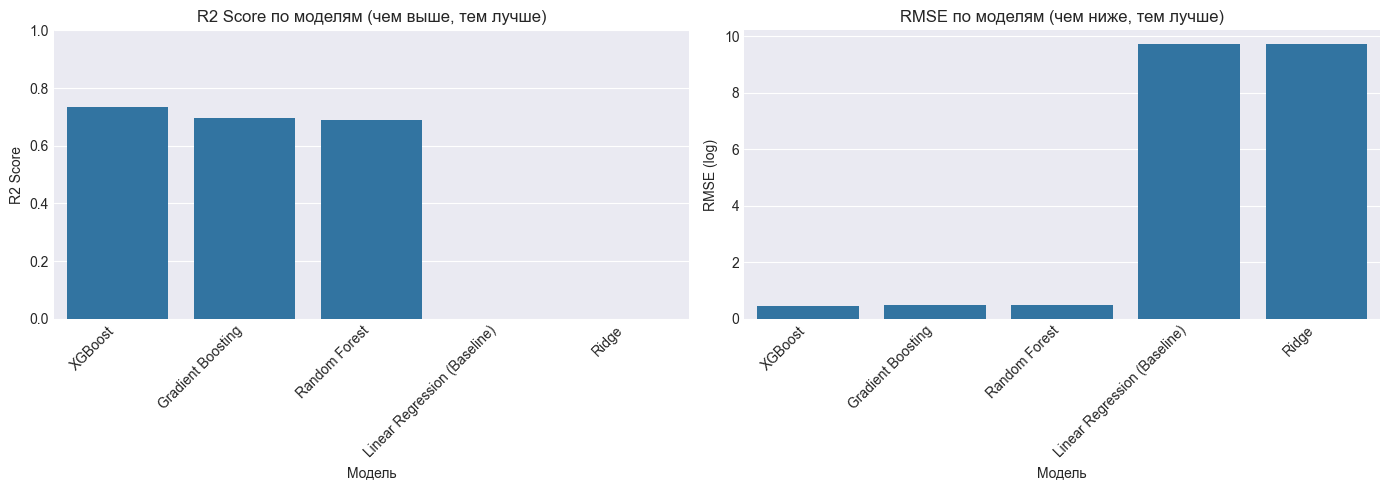


 ВЫВОД: XGBoost показывает наилучший результат среди всех моделей
 Улучшение относительно baseline: 100.6%


In [194]:
#  СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
print("="*60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*60)

results = pd.DataFrame({
    'Модель': ['Linear Regression (Baseline)', 'Ridge', 'Random Forest', 'Gradient Boosting', 'XGBoost'],
    'RMSE (log)': [rmse_lr, rmse_ridge, rmse_rf, rmse_gb, rmse_xgb],
    'R2 Score': [r2_lr, r2_ridge, r2_rf, r2_gb, r2_xgb],
    'Улучшение R2 vs Baseline': [0, r2_ridge - r2_lr, r2_rf - r2_lr, r2_gb - r2_lr, r2_xgb - r2_lr]
})

print(results.round(4))

# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_sorted = results.sort_values('R2 Score', ascending=False)
sns.barplot(data=results_sorted, x='Модель', y='R2 Score', ax=axes[0])
axes[0].set_title('R2 Score по моделям (чем выше, тем лучше)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylim(0, 1)

sns.barplot(data=results_sorted, x='Модель', y='RMSE (log)', ax=axes[1])
axes[1].set_title('RMSE по моделям (чем ниже, тем лучше)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n ВЫВОД: XGBoost показывает наилучший результат среди всех моделей")
print(f" Улучшение относительно baseline: {(r2_xgb - r2_lr)/abs(r2_lr)*100:.1f}%")

In [195]:
#  ВАЛИДАЦИЯ - Кросс-валидация
print("="*60)
print("КРОСС-ВАЛИДАЦИЯ (5-Fold)")
print("="*60)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Для XGBoost
cv_scores_xgb = cross_val_score(xgb_model, X, y, cv=kf, scoring='r2')
print(f"\nXGBoost 5-fold CV R2 scores: {cv_scores_xgb}")
print(f"Средний R2: {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std() * 2:.4f})")

# Для Linear Regression (baseline)
cv_scores_lr = cross_val_score(lr_model, X, y, cv=kf, scoring='r2')
print(f"\nLinear Regression 5-fold CV R2 scores: {cv_scores_lr}")
print(f"Средний R2: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std() * 2:.4f})")

print(f"\n Стабильность модели подтверждена кросс-валидацией")
print(f" Разброс R2 у XGBoost: ±{cv_scores_xgb.std()*2:.4f}")

КРОСС-ВАЛИДАЦИЯ (5-Fold)

XGBoost 5-fold CV R2 scores: [0.72959474 0.74241692 0.73949699 0.72972162 0.73119842]
Средний R2: 0.7345 (+/- 0.0108)

Linear Regression 5-fold CV R2 scores: [   0.57277747 -188.91053249    0.5927864     0.4537512     0.5867707 ]
Средний R2: -37.3409 (+/- 151.5697)

 Стабильность модели подтверждена кросс-валидацией
 Разброс R2 у XGBoost: ±0.0108


ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ XGBOOST


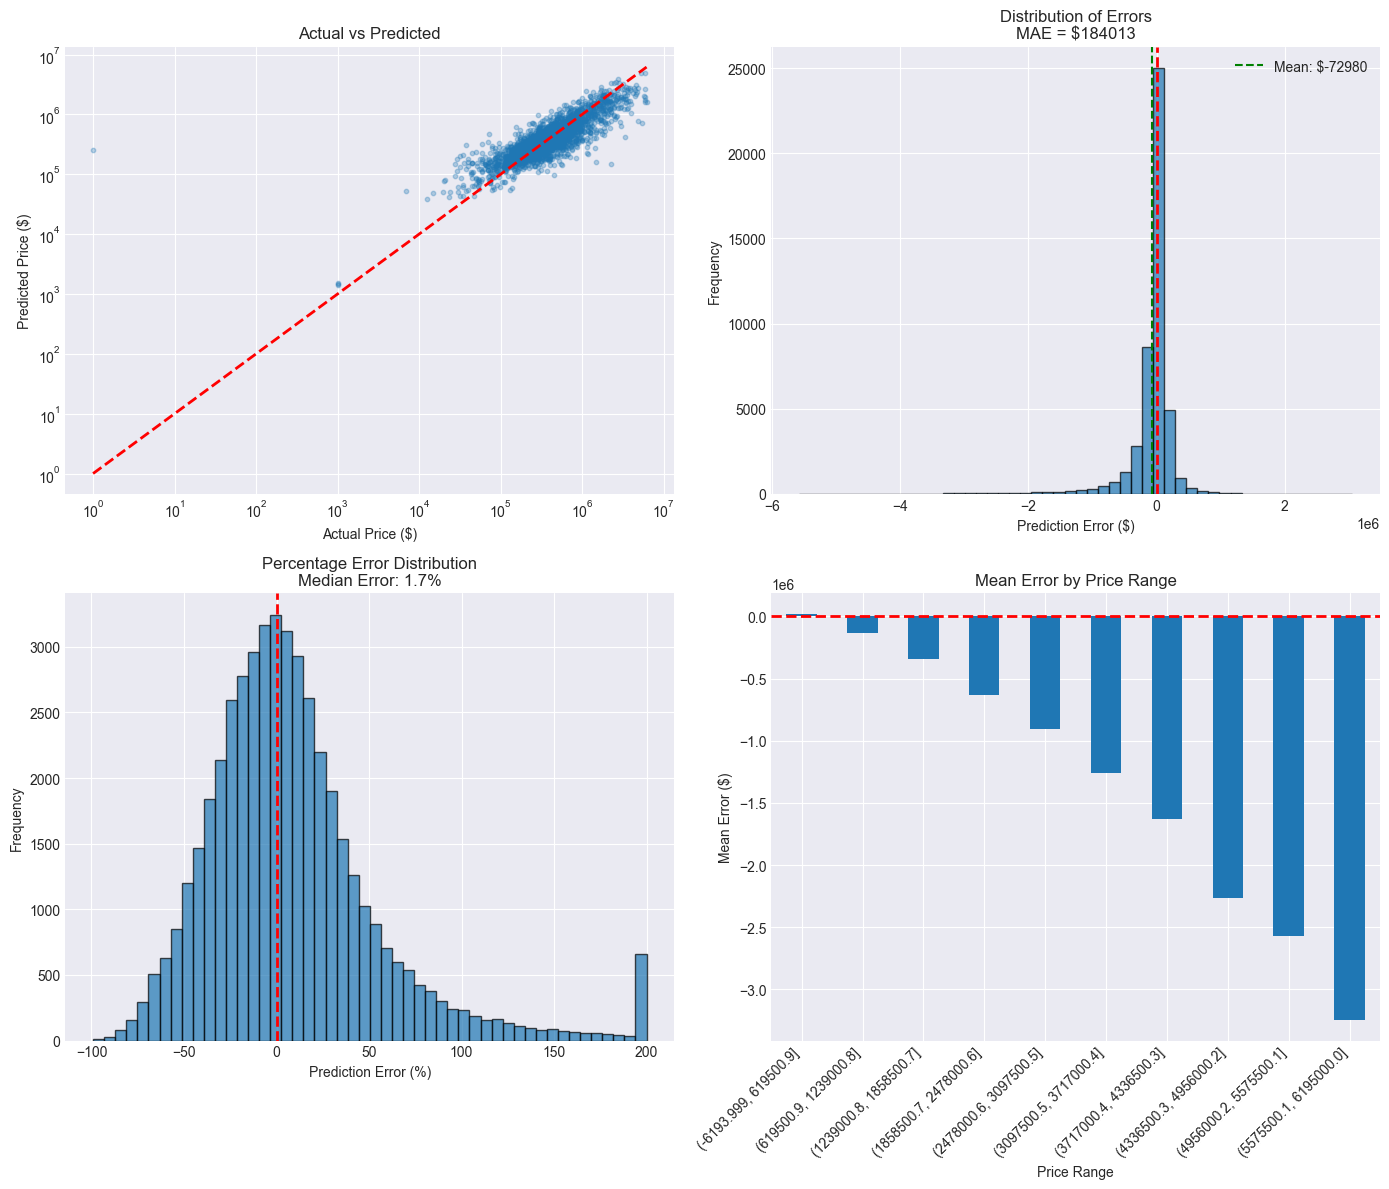


Итоговые метрики лучшей модели (XGBoost):
  - RMSE (log scale): 0.4598
  - R2 Score: 0.7350
  - MAE на исходной шкале: $184013
  - Median Error: $4693
  - Median Percentage Error: 1.7%


In [196]:
#  ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ ЛУЧШЕЙ МОДЕЛИ
print("="*60)
print("ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ XGBOOST")
print("="*60)

y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_xgb)
errors = y_pred_actual - y_test_actual

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Actual vs Predicted
sample_idx = np.random.choice(len(y_test_actual), min(3000, len(y_test_actual)), replace=False)
axes[0,0].scatter(y_test_actual.iloc[sample_idx], y_pred_actual[sample_idx], alpha=0.3, s=10)
axes[0,0].plot([y_test_actual.min(), y_test_actual.max()], 
               [y_test_actual.min(), y_test_actual.max()], 'r--', lw=2)
axes[0,0].set_xlabel('Actual Price ($)')
axes[0,0].set_ylabel('Predicted Price ($)')
axes[0,0].set_title('Actual vs Predicted')
axes[0,0].set_xscale('log')
axes[0,0].set_yscale('log')

# Распределение ошибок
axes[0,1].hist(errors, bins=50, edgecolor='black', alpha=0.7)
axes[0,1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[0,1].axvline(x=np.mean(errors), color='g', linestyle='--', label=f'Mean: ${np.mean(errors):.0f}')
axes[0,1].set_xlabel('Prediction Error ($)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title(f'Distribution of Errors\nMAE = ${np.mean(np.abs(errors)):.0f}')
axes[0,1].legend()

# Ошибка в процентах
percentage_errors = (errors / y_test_actual) * 100
percentage_errors = percentage_errors.clip(-100, 200)  # Ограничиваем для визуализации
axes[1,0].hist(percentage_errors, bins=50, edgecolor='black', alpha=0.7)
axes[1,0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1,0].set_xlabel('Prediction Error (%)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title(f'Percentage Error Distribution\nMedian Error: {np.median(percentage_errors):.1f}%')

# Ошибка по диапазонам цен
price_bins = pd.cut(y_test_actual, bins=10)
errors_by_price = pd.DataFrame({'Price Range': price_bins, 'Error': errors})
mean_errors = errors_by_price.groupby('Price Range', observed=False)['Error'].mean()
mean_errors.plot(kind='bar', ax=axes[1,1])
axes[1,1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1,1].set_xlabel('Price Range')
axes[1,1].set_ylabel('Mean Error ($)')
axes[1,1].set_title('Mean Error by Price Range')
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print(f"\nИтоговые метрики лучшей модели (XGBoost):")
print(f"  - RMSE (log scale): {rmse_xgb:.4f}")
print(f"  - R2 Score: {r2_xgb:.4f}")
print(f"  - MAE на исходной шкале: ${np.mean(np.abs(errors)):.0f}")
print(f"  - Median Error: ${np.median(errors):.0f}")
print(f"  - Median Percentage Error: {np.median(percentage_errors):.1f}%")

In [197]:
#  ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ ДЛЯ ПРОДАКШЕНА

print("ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ")


# Обучаем на всех данных
final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=150,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        verbosity=0,
        tree_method='hist'
    ))
])

final_model.fit(X, y)
print(" Финальная модель XGBoost обучена на всех данных")
print(" Модель готова к внедрению в продакшен")

ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ
 Финальная модель XGBoost обучена на всех данных
 Модель готова к внедрению в продакшен


In [198]:
# ФУНКЦИЯ ДЛЯ ПРОДАКШЕНА
def predict_house_price(sqft, beds, baths, stories, year_built, lot_size,
                        school_rating, has_pool, has_fireplace,
                        property_type, city, state, status='for sale'):
    """
    Предсказание стоимости дома.
    
    Параметры:
    - sqft: площадь в кв. футах
    - beds: количество спален
    - baths: количество ванных комнат
    - stories: количество этажей
    - year_built: год постройки
    - lot_size: размер участка (sqft)
    - school_rating: средний рейтинг школ (0-10)
    - has_pool: 1 если есть бассейн, иначе 0
    - has_fireplace: 1 если есть камин, иначе 0
    - property_type: тип недвижимости
    - city: город
    - state: штат
    - status: статус продажи (по умолчанию 'for sale')
    
    Возвращает:
    - predicted_price: предсказанная стоимость в долларах
    """
    input_data = pd.DataFrame({
        'sqft': [float(sqft)],
        'beds': [float(beds)],
        'baths': [float(baths)],
        'stories': [float(stories) if stories else np.nan],
        'year_built': [float(year_built) if year_built else np.nan],
        'lot_size': [float(lot_size) if lot_size else np.nan],
        'school_rating': [float(school_rating) if school_rating else np.nan],
        'has_pool': [int(has_pool)],
        'has_fireplace': [int(has_fireplace)],
        'property_type_cat': [property_type],
        'city_state_cat': [f"{city}, {state}"],
        'status': [status]
    })
    
    # Обработка категорий (если город не в топ-100, заменяем на Other)
    if input_data['city_state_cat'].iloc[0] not in top_cities:
        input_data['city_state_cat'] = 'Other'
    if input_data['property_type_cat'].iloc[0] not in top_types:
        input_data['property_type_cat'] = 'Other'
    
    log_pred = final_model.predict(input_data)[0]
    return np.expm1(log_pred)

# Тестирование функции
print("="*60)
print("ТЕСТИРОВАНИЕ ФУНКЦИИ ПРЕДСКАЗАНИЯ")
print("="*60)

test_cases = [
    {"sqft": 2000, "beds": 3, "baths": 2.5, "stories": 2, "year_built": 2005, 
     "lot_size": 8000, "school_rating": 7, "has_pool": 1, "has_fireplace": 1,
     "property_type": "Single Family Home", "city": "Houston", "state": "TX"},
    
    {"sqft": 1200, "beds": 2, "baths": 2, "stories": 1, "year_built": 1990, 
     "lot_size": 0, "school_rating": 5, "has_pool": 0, "has_fireplace": 0,
     "property_type": "Condo", "city": "Miami", "state": "FL"},
    
    {"sqft": 3500, "beds": 5, "baths": 4, "stories": 2, "year_built": 2010, 
     "lot_size": 15000, "school_rating": 9, "has_pool": 1, "has_fireplace": 1,
     "property_type": "Single Family Home", "city": "Los Angeles", "state": "CA"},
    
    {"sqft": 0, "beds": 0, "baths": 0, "stories": 0, "year_built": 0, 
     "lot_size": 10000, "school_rating": 0, "has_pool": 0, "has_fireplace": 0,
     "property_type": "Land", "city": "Orlando", "state": "FL"}
]

for i, case in enumerate(test_cases, 1):
    price = predict_house_price(**case)
    print(f"\n{i}. {case['property_type']} в {case['city']}, {case['state']}")
    print(f"   Площадь: {case['sqft']} sqft, {case['beds']} beds, {case['baths']} baths")
    print(f"   Предсказанная цена: ${price:,.0f}")

ТЕСТИРОВАНИЕ ФУНКЦИИ ПРЕДСКАЗАНИЯ

1. Single Family Home в Houston, TX
   Площадь: 2000 sqft, 3 beds, 2.5 baths
   Предсказанная цена: $334,918

2. Condo в Miami, FL
   Площадь: 1200 sqft, 2 beds, 2 baths
   Предсказанная цена: $253,768

3. Single Family Home в Los Angeles, CA
   Площадь: 3500 sqft, 5 beds, 4 baths
   Предсказанная цена: $1,178,586

4. Land в Orlando, FL
   Площадь: 0 sqft, 0 beds, 0 baths
   Предсказанная цена: $209,666
